In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Iris dataset loaded. Features: {feature_names}")
print(f"Target classes: {target_names}")

Iris dataset loaded. Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
# 2. Initialize and train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics (using 'weighted' precision for multi-class)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision (Weighted)": prec}
    conf_matrices[name] = cm

# Display metrics
results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision (Weighted)
Logistic Regression,1.0,1.0
Decision Tree,1.0,1.0
Random Forest,1.0,1.0


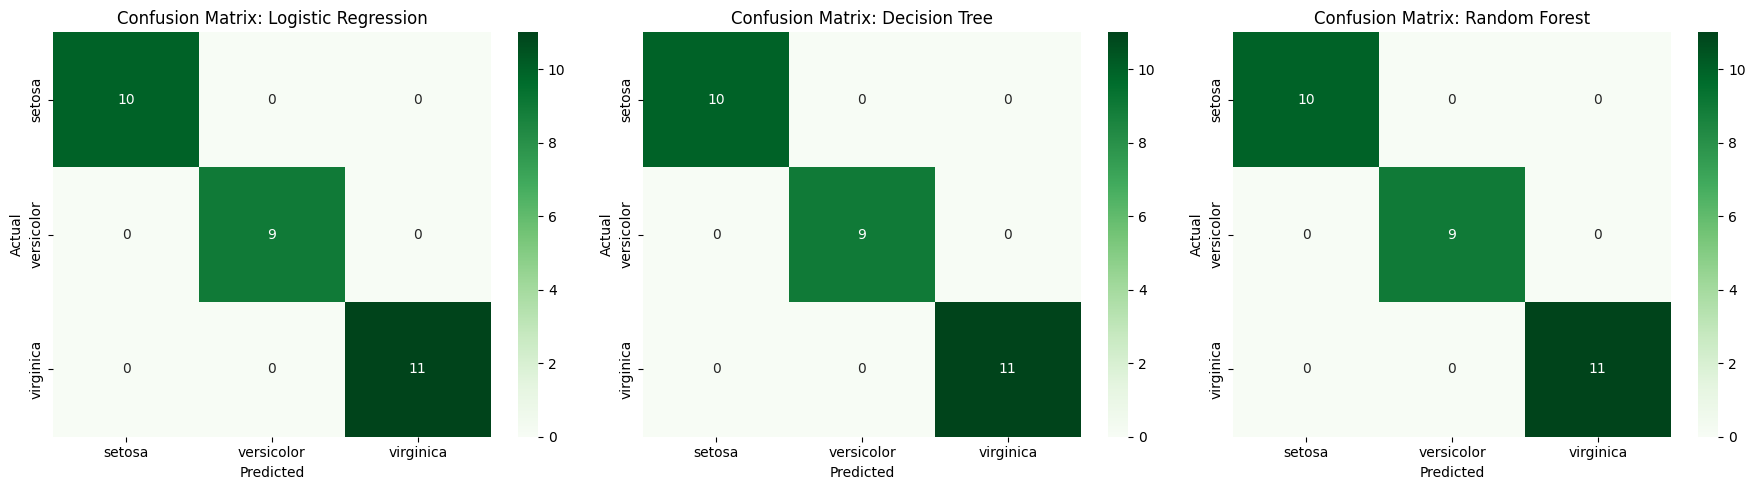

In [ ]:
# 3. Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Greens',
                xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

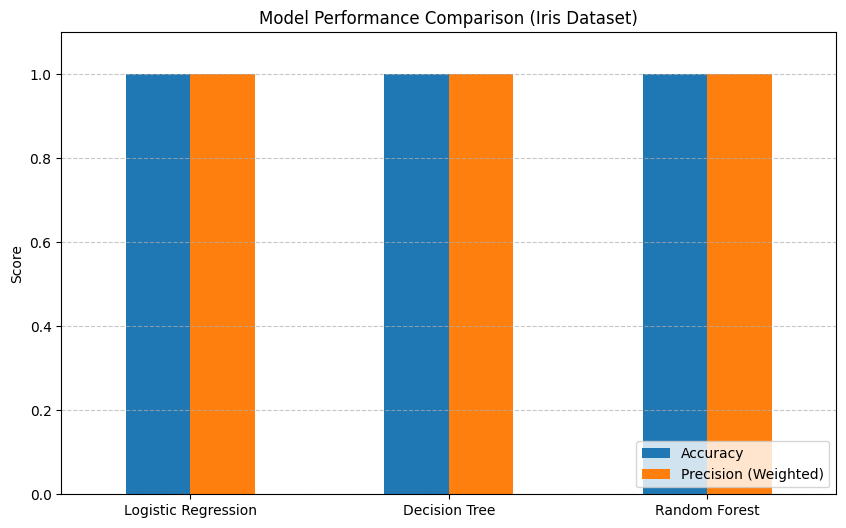

In [ ]:
# 4. Compare Performance in a Graph
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison (Iris Dataset)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.0, 1.1) # Adjusted to show full range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()